# V43 (Option B): LQ45 AI Strategy with Long-Term Trend Filter (MA200)

**Objective**: Reduce 'Whipsaw' (frequent switching) by replacing the sensitive MA50 with a robust **200-Day Moving Average (MA200)**.

### Modification (MA200 Logic):
The 200-day moving average is the standard for defining long-term bull/bear markets. It is significantly slower and smoother than the MA50.

**New Logic:**
- **Risk-On Condition (Stay Invested)**:
  - IF (AI Prob >= 0.60) **OR** (Market Price > MA200).
  - *Interpretation*: We trust the long-term trend. If the market is above MA200, we ignore short-term AI bearishness.
- **Risk-Off Condition (Cash)**:
  - IF (AI Prob < 0.60) **AND** (Market Price < MA200).
  - *Interpretation*: We only exit to Cash if the AI is scared AND the long-term trend is broken (Bear Market).

**Rationale**:
- MA200 filters out almost all short-term noise and corrections, only exiting during major structural declines.

### Comparisons:
1. **AI Hybrid V43 (MA200)**.
2. **Markowitz Static (Baseline)**.
3. **IHSG Proxy (Benchmark)**.


In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- 1. Load Data (LQ45) ---
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
market_price = (1 + market_return).cumprod() * 100

print(f"Data Loaded: {len(data)} rows")


Data Loaded: 712 rows


In [2]:
# --- 2. Feature Engineering & AI Model ---

features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
ma5 = market_price.rolling(window=5).mean()
ma20 = market_price.rolling(window=20).mean()
ma50 = market_price.rolling(window=50).mean()
# Add MA200 for V43 Option B
ma200 = market_price.rolling(window=200).mean()

features['Dist_MA20'] = market_price / ma20
features['Dist_MA50'] = market_price / ma50

# Calculate Trend Signal: Price > MA200
trend_bullish_ma200 = (market_price > ma200).astype(int)

# TARGET: MA Slope Direction
target = (ma5.shift(-1) > ma5).astype(int)

features = features.dropna()
target = target.reindex(features.index).fillna(0)
trend_bullish_ma200 = trend_bullish_ma200.reindex(features.index).fillna(0)

train_mask = (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X_train, y_train = features.loc[train_mask], target.loc[train_mask]
X_test = features.loc[test_mask]

xgb_model = xgb.XGBClassifier(n_estimators=120, learning_rate=0.04, max_depth=6, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

opt_t = 0.60
print(f"[Strategy] Using Base Threshold: {opt_t:.2f} with MA200 Long-Term Trend Override")


[Strategy] Using Base Threshold: 0.60 with MA200 Long-Term Trend Override


In [3]:
# --- 3. Simulation Logic (V43 MA200) ---

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    sigma += np.eye(len(sigma)) * 1e-4 
    try:
        res = minimize(lambda w: -(np.sum(w*mu)/(np.sqrt(np.dot(w.T, np.dot(sigma, w))) + 1e-6)), 
                       [1./len(mu)]*len(mu), method='SLSQP', 
                       bounds=tuple((0, 1) for _ in range(len(mu))), 
                       constraints=({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}))
        return dict(zip(selected_returns.columns, res.x)) if res.success else {}
    except:
        return {}

def run_simulation_ma200(strategy_type, test_dates, returns, ai_probs=None, trend_signal=None, threshold=0.5, fee=0.0025):
    val, history, dates = 100.0, [100.0], [test_dates[0]]
    prev_weights = {}
    static_weights = None
    state_history = []
    
    for i, date in enumerate(test_dates[:-1]):
        loc_idx = returns.index.get_loc(date)
        window_rets = returns.iloc[loc_idx-30:loc_idx]
        
        current_state = "Neutral"
        weights = {}

        if strategy_type == 'AI Hybrid V43 (MA200)':
            prob = ai_probs.loc[date]
            # Trend Signal is Price > MA200
            is_trend_up = trend_signal.loc[date] == 1
            
            # HYBRID LOGIC V43:
            # Exit ONLY if AI is scared (< T) AND Long-Term Trend is Broken (< MA200).
            is_risk_off = (prob < threshold) and (not is_trend_up)
            
            if is_risk_off: 
                weights = {'CASH': 1.0}
                current_state = "Cash (Bear Market)"
            else:
                # Risk On
                valid_assets = window_rets.dropna(axis=1, how='any').columns
                weights = optimize_markowitz(window_rets[valid_assets])
                current_state = "Invested"
                
        elif strategy_type == 'Markowitz Static':
            if static_weights is None:
                valid_assets = window_rets.dropna(axis=1, how='any').columns
                static_weights = optimize_markowitz(window_rets[valid_assets])
            weights = static_weights
            current_state = "Static"
        
        state_history.append(current_state)
        
        # Transaction Costs
        all_assets = set(list(weights.keys()) + list(prev_weights.keys()))
        turnover = sum(abs(weights.get(a, 0) - prev_weights.get(a, 0)) for a in all_assets)
        val -= (val * turnover * fee)
        
        next_date = test_dates[i+1]
        day_ret = 0 if 'CASH' in weights else sum(w * returns.loc[next_date, a] for a, w in weights.items())
        val *= (1 + day_ret)
        history.append(val); dates.append(next_date); prev_weights = weights
        
    return pd.DataFrame({'Portfolio_Value': history, 'State': state_history + [state_history[-1]]}, index=dates)


In [4]:
# --- 4. Models & Benchmark Execution ---
ai_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=X_test.index)
test_trend_ma200 = trend_bullish_ma200.loc[X_test.index]

print("Running AI Hybrid V43 (MA200)...")
hybrid_res_v43_ma200 = run_simulation_ma200('AI Hybrid V43 (MA200)', X_test.index, returns, ai_probs, test_trend_ma200, threshold=opt_t)

print("Running Markowitz Static...")
static_res = run_simulation_ma200('Markowitz Static', X_test.index, returns)

print("Calculating IHSG Benchmark...")
ihsg_ret = market_return.loc[X_test.index]
ihsg_price = (1 + ihsg_ret).cumprod() * 100


Running AI Hybrid V43 (MA200)...
Running Markowitz Static...
Calculating IHSG Benchmark...


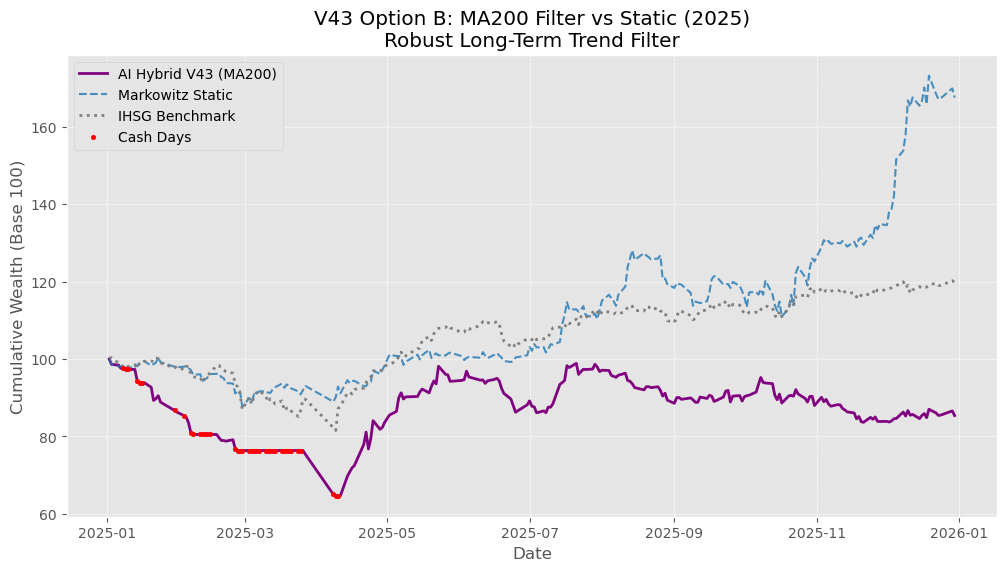

Total Regime Switches in V43 (MA200): 15


In [5]:
# --- Visualization: Performance Comparison ---
plt.figure(figsize=(12, 6))
plt.plot(hybrid_res_v43_ma200['Portfolio_Value'], label=f'AI Hybrid V43 (MA200)', color='purple', linewidth=2)
plt.plot(static_res['Portfolio_Value'], label='Markowitz Static', color='#1f77b4', linestyle='--', alpha=0.8)
plt.plot(ihsg_price, label='IHSG Benchmark', color='#7f7f7f', linestyle=':', linewidth=2)

# Highlight Regime Switches
regime_switches = hybrid_res_v43_ma200[hybrid_res_v43_ma200['State'].str.contains('Cash')]
plt.scatter(regime_switches.index, regime_switches['Portfolio_Value'], color='red', s=10, label='Cash Days', zorder=5)

plt.title(f'V43 Option B: MA200 Filter vs Static (2025)\nRobust Long-Term Trend Filter')
plt.ylabel('Cumulative Wealth (Base 100)')
plt.xlabel('Date')
plt.legend(loc='upper left')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.savefig('v43_ma200_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate switches count
switches_count = (hybrid_res_v43_ma200['State'] != hybrid_res_v43_ma200['State'].shift(1)).sum()
print(f"Total Regime Switches in V43 (MA200): {switches_count}")
